# Volatility (Last 1 Year) ? Sector ETFs + Gold

This notebook visualizes **realized volatility** using a short 5-day rolling window, annualized with ?252.
It focuses on sector ETFs plus gold, aligned with intra-week options use cases.

Tickers: XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY, XLC, GLD

Note: 5-day rolling vol is **noisy**; it reacts quickly but can be jumpy. If you want a smoother signal, compare to 20-day or use a blend.

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Parameters
tickers = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY", "XLC", "GLD"]
window = 5  # trading days
annualization = 252

end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.Timedelta(days=365)

tickers

['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY', 'XLC', 'GLD']

In [7]:
# Download adjusted close prices
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
close = data["Close"] if "Close" in data.columns else data

# Ensure DataFrame shape when single column is returned
if isinstance(close, pd.Series):
    close = close.to_frame()

close.tail()

Ticker,GLD,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,,
2026-01-26,464.700012,50.029999,117.769997,49.220001,53.410000,164.380005,146.080002,82.779999,42.869999,158.100006,122.320000
2026-01-27,476.100006,49.980000,116.900002,49.669998,53.000000,165.059998,148.050003,83.160004,43.430000,155.449997,122.690002
2026-01-28,494.559998,49.950001,116.750000,50.049999,52.990002,164.139999,149.229996,82.320000,43.330002,154.309998,121.769997
2026-01-29,495.899994,50.000000,119.790001,50.509998,53.549999,165.860001,146.869995,82.129997,43.330002,153.820007,121.190002
2026-01-30,444.950012,49.270000,120.080002,51.049999,53.439999,165.440002,143.880005,83.510002,43.250000,154.740005,121.169998


In [8]:
# Daily returns
returns = close.pct_change().dropna(how="all")

# 5-day rolling annualized volatility
vol = returns.rolling(window).std() * np.sqrt(annualization)

vol.tail()

Ticker,GLD,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,,
2026-01-26,0.162247,0.184274,0.178363,0.164166,0.216771,0.217484,0.246960,0.063552,0.109098,0.146099,0.275399
2026-01-27,0.071355,0.142383,0.128979,0.146954,0.149184,0.155940,0.082285,0.066590,0.129353,0.204112,0.150497
2026-01-28,0.163195,0.069372,0.131096,0.054147,0.141315,0.079348,0.067862,0.109397,0.133411,0.125648,0.119046
2026-01-29,0.214983,0.065262,0.199956,0.056591,0.158049,0.117114,0.178443,0.109664,0.111994,0.118957,0.087478
2026-01-30,0.897467,0.105829,0.201630,0.063113,0.113909,0.098545,0.243874,0.159185,0.106468,0.145463,0.071124


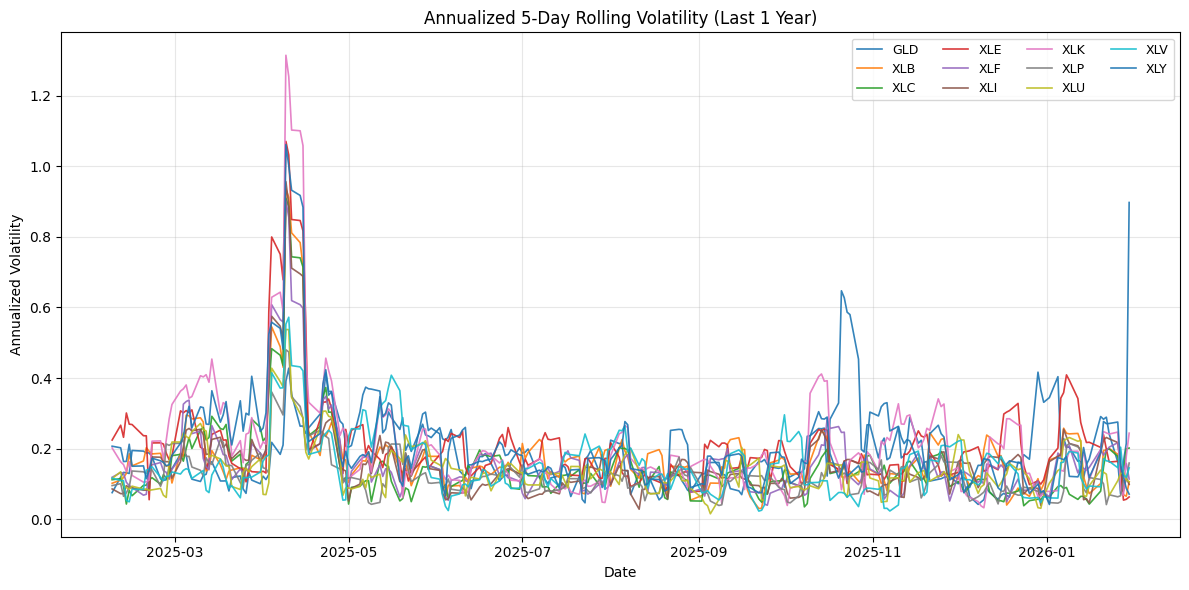

In [9]:
# Plot volatility series
plt.figure(figsize=(12, 6))
for col in vol.columns:
    plt.plot(vol.index, vol[col], label=col, linewidth=1.2, alpha=0.9)

plt.title(f"Annualized {window}-Day Rolling Volatility (Last 1 Year)")
plt.ylabel("Annualized Volatility")
plt.xlabel("Date")
plt.legend(ncol=4, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

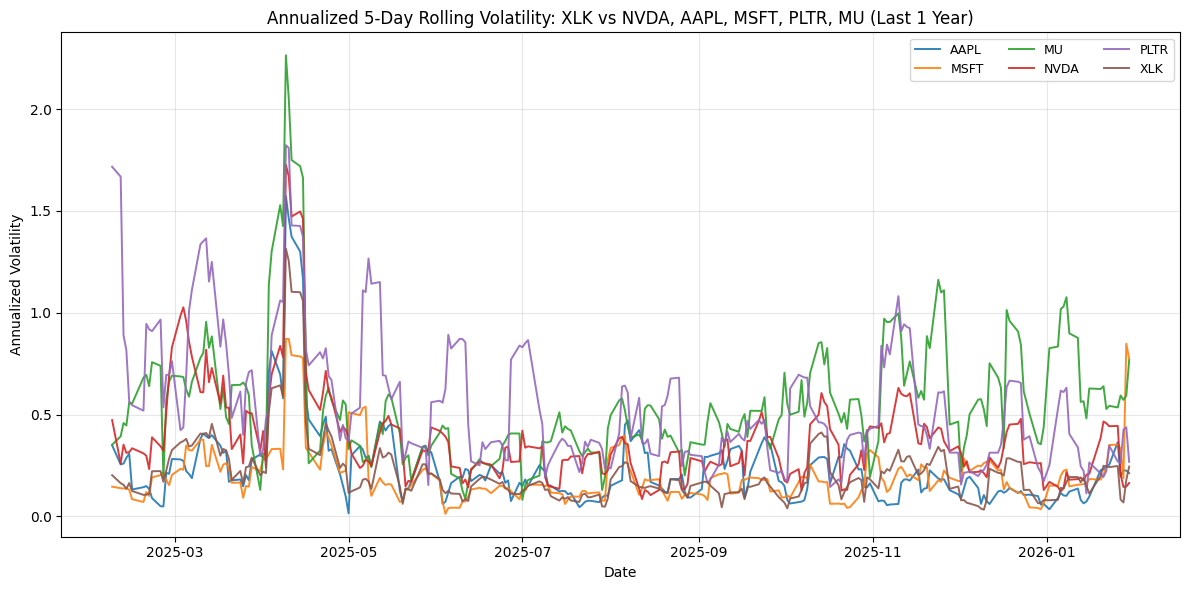

In [10]:
# Compare XLK vs NVDA, AAPL, MSFT, PLTR, MU
compare_tickers = ["XLK", "NVDA", "AAPL", "MSFT", "PLTR", "MU"]

compare_data = yf.download(compare_tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
compare_close = compare_data["Close"] if "Close" in compare_data.columns else compare_data

if isinstance(compare_close, pd.Series):
    compare_close = compare_close.to_frame()

compare_returns = compare_close.pct_change().dropna(how="all")
compare_vol = compare_returns.rolling(window).std() * np.sqrt(annualization)

plt.figure(figsize=(12, 6))
for col in compare_vol.columns:
    plt.plot(compare_vol.index, compare_vol[col], label=col, linewidth=1.4, alpha=0.9)

plt.title(f"Annualized {window}-Day Rolling Volatility: XLK vs NVDA, AAPL, MSFT, PLTR, MU (Last 1 Year)")
plt.ylabel("Annualized Volatility")
plt.xlabel("Date")
plt.legend(ncol=3, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
# Latest volatility snapshot
latest_vol = vol.iloc[-1].sort_values(ascending=False)
latest_vol

Ticker
GLD    0.897467
XLK    0.243874
XLC    0.201630
XLP    0.159185
XLV    0.145463
XLF    0.113909
XLU    0.106468
XLB    0.105829
XLI    0.098545
XLY    0.071124
XLE    0.063113
Name: 2026-01-30 00:00:00, dtype: float64